# Day 6 - Advanced Mutual Fund Analytics

## Historical VaR & CVaR
## Rolling Sharpe Ratio
## Investor Cohort Analysis
## SIP Continuity Analysis
## Fund Recommender
## Sector HHI Analysis
## Advanced Insights

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
fund_scorecard = pd.read_csv(
    "../reports/fund_scorecard.csv"
)

alpha_beta = pd.read_csv(
    "../reports/alpha_beta.csv"
)

print(fund_scorecard.head())

   amfi_code      cagr  sharpe_ratio     alpha      beta  max_drawdown  \
0     100016  0.026352     -0.201517  0.037476 -0.058268     -0.247344   
1     100025  0.044551     -0.567095  0.042818  0.001158     -0.043083   
2     100033  0.300997      1.093699  0.271954  0.005104     -0.162172   
3     101206  0.235205      1.027213  0.213998  0.021086     -0.112916   
4     101207  0.079331      0.162661  0.108971 -0.065289     -0.354469   

   expense_ratio_pct  return_rank  sharpe_rank  alpha_rank  expense_rank  \
0               1.55         37.0         35.0        39.0          32.0   
1               0.56         36.0         39.0        38.0           2.0   
2               1.38          7.0          7.0         6.0          17.0   
3               1.60         12.0          9.0        12.0          36.5   
4               1.53         27.0         28.0        27.0          28.5   

   drawdown_rank  fund_score  
0           34.0    1.110162  
1            4.0   25.021349  
2    

In [5]:
print(fund_scorecard.columns)

Index(['amfi_code', 'cagr', 'sharpe_ratio', 'alpha', 'beta', 'max_drawdown',
       'expense_ratio_pct', 'return_rank', 'sharpe_rank', 'alpha_rank',
       'expense_rank', 'drawdown_rank', 'fund_score'],
      dtype='str')


In [11]:
import pandas as pd
import numpy as np

nav = pd.read_csv("../data/raw/02_nav_history.csv")
transactions = pd.read_csv("../data/raw/08_investor_transactions.csv")
fund_master = pd.read_csv("../data/raw/01_fund_master.csv")

print(nav.head())
print(nav.columns)

   amfi_code        date      nav
0     119551  2022-01-03  54.3856
1     119551  2022-01-04  54.3474
2     119551  2022-01-05  54.6869
3     119551  2022-01-06  55.4550
4     119551  2022-01-07  55.3692
Index(['amfi_code', 'date', 'nav'], dtype='str')


In [12]:
print(nav.columns.tolist())

['amfi_code', 'date', 'nav']


In [13]:
nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(
    ["amfi_code","date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
    .pct_change()
)

daily_returns = nav.dropna()

daily_returns.head()

,amfi_code,date,nav,daily_return
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210
5755,100016,2022-01-10,510.7136,-0.008639


## Historical VaR and CVaR

In [14]:
var_results = []

for fund in daily_returns["amfi_code"].unique():

    returns = daily_returns[
        daily_returns["amfi_code"] == fund
    ]["daily_return"]

    if len(returns) > 30:

        var95 = np.percentile(
            returns,
            5
        )

        cvar95 = returns[
            returns <= var95
        ].mean()

        var_results.append([
            fund,
            var95,
            cvar95
        ])

var_df = pd.DataFrame(
    var_results,
    columns=[
        "amfi_code",
        "VaR_95",
        "CVaR_95"
    ]
)

var_df.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [15]:
var_df.to_csv(
    "../reports/var_cvar_report.csv",
    index=False
)

print("Saved Successfully")

Saved Successfully


## Rolling 90 Day Sharpe Ratio

rolling_sharpe = []

top5 = (
    fund_scorecard
    .sort_values(
        "sharpe_ratio",
        ascending=False
    )
    .head(5)
)

top_funds = top5["amfi_code"]

In [17]:
top5 = (
    fund_scorecard
    .sort_values(
        "sharpe_ratio",
        ascending=False
    )
    .head(5)
)

top_funds = top5["amfi_code"]

print(top_funds)

34    148567
30    120843
36    148569
19    119551
25    120505
Name: amfi_code, dtype: int64


In [18]:
print(daily_returns.head())

      amfi_code       date       nav  daily_return
5751     100016 2022-01-04  515.0971     -0.010306
5752     100016 2022-01-05  521.7239      0.012865
5753     100016 2022-01-06  515.7880     -0.011377
5754     100016 2022-01-07  515.1639     -0.001210
5755     100016 2022-01-10  510.7136     -0.008639


In [19]:
print(top_funds)
print(daily_returns.head())

34    148567
30    120843
36    148569
19    119551
25    120505
Name: amfi_code, dtype: int64
      amfi_code       date       nav  daily_return
5751     100016 2022-01-04  515.0971     -0.010306
5752     100016 2022-01-05  521.7239      0.012865
5753     100016 2022-01-06  515.7880     -0.011377
5754     100016 2022-01-07  515.1639     -0.001210
5755     100016 2022-01-10  510.7136     -0.008639


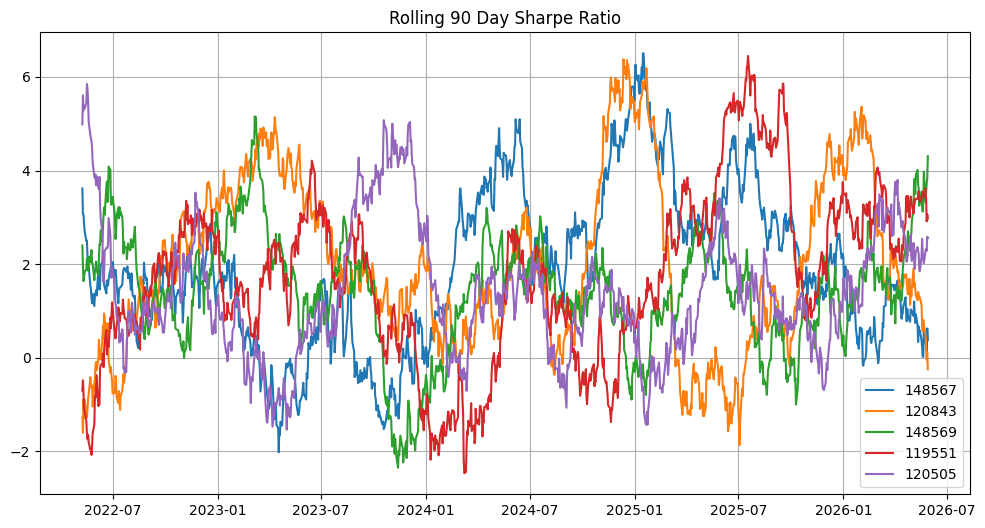

In [20]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12,6))

for fund in top_funds:

    temp = daily_returns[
        daily_returns["amfi_code"] == fund
    ].copy()

    temp["rolling_sharpe"] = (
        temp["daily_return"]
        .rolling(90)
        .mean()
        /
        temp["daily_return"]
        .rolling(90)
        .std()
    ) * np.sqrt(252)

    plt.plot(
        temp["date"],
        temp["rolling_sharpe"],
        label=str(fund)
    )

plt.legend()
plt.title("Rolling 90 Day Sharpe Ratio")
plt.grid(True)

plt.savefig(
    "../reports/rolling_sharpe_chart.png"
)

plt.show()

# Investor Cohort Analysis

In [22]:
import pandas as pd

investor_transactions = pd.read_csv(
    "../data/raw/08_investor_transactions.csv"
)

print(investor_transactions.head())

  investor_id transaction_date  amfi_code transaction_type  amount_inr  \
0   INV003054       2024-01-01     119092              SIP        1834   
1   INV002952       2024-01-01     148567       Redemption      392882   
2   INV003420       2024-01-01     118636              SIP         912   
3   INV003436       2024-01-01     118634              SIP        1102   
4   INV004691       2024-01-01     119094          Lumpsum        8682   

         state       city city_tier age_group  gender  annual_income_lakh  \
0    Telangana  Hyderabad       T30       56+  Female                77.1   
1       Punjab   Amritsar       B30     18-25    Male                 7.1   
2      Haryana  Faridabad       B30     36-45    Male                47.2   
3  Maharashtra     Mumbai       T30     36-45  Female                54.4   
4        Delhi      Noida       T30     26-35    Male                14.5   

  payment_mode kyc_status  
0          UPI   Verified  
1       Cheque   Verified  
2      M

In [23]:
print(investor_transactions.columns)

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='str')


In [24]:
investor_transactions["transaction_date"] = pd.to_datetime(
    investor_transactions["transaction_date"]
)

first_txn = (
    investor_transactions
    .groupby("investor_id")
    ["transaction_date"]
    .min()
    .reset_index()
)

first_txn["cohort_year"] = (
    first_txn["transaction_date"]
    .dt.year
)

first_txn.head()

,investor_id,transaction_date,cohort_year
0,INV000001,2024-11-04,2024
1,INV000002,2024-03-29,2024
2,INV000003,2024-07-16,2024
3,INV000004,2024-03-16,2024
4,INV000005,2024-04-27,2024


In [25]:
investor_transactions = (
    investor_transactions.merge(
        first_txn[
            ["investor_id","cohort_year"]
        ],
        on="investor_id"
    )
)

investor_transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified,2024
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending,2024


In [26]:
cohort_analysis = (
    investor_transactions
    .groupby("cohort_year")
    .agg(
        avg_sip_amount = (
            "amount_inr",
            "mean"
        ),
        total_invested = (
            "amount_inr",
            "sum"
        )
    )
    .reset_index()
)

cohort_analysis

,cohort_year,avg_sip_amount,total_invested
0,2024,107422.541832,3491125187
1,2025,109158.577061,30455243


In [27]:
top_fund_pref = (
    investor_transactions
    .groupby(
        ["cohort_year","amfi_code"]
    )
    ["amount_inr"]
    .sum()
    .reset_index()
)

top_fund_pref = (
    top_fund_pref
    .sort_values(
        ["cohort_year","amount_inr"],
        ascending=False
    )
    .groupby("cohort_year")
    .head(1)
)

top_fund_pref

,cohort_year,amfi_code,amount_inr
62,2025,119599,1478507
6,2024,102885,100126141


In [28]:
cohort_analysis.to_csv(
    "../reports/cohort_analysis.csv",
    index=False
)

top_fund_pref.to_csv(
    "../reports/cohort_top_fund.csv",
    index=False
)

print("Cohort Analysis Saved")

Cohort Analysis Saved


# SIP Continuity Analysis

In [29]:
print(investor_transactions.columns)

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status', 'cohort_year'],
      dtype='str')


In [30]:
sip_txns = investor_transactions[
    investor_transactions["transaction_type"] == "SIP"
].copy()

print(sip_txns.shape)
sip_txns.head()

(19716, 14)


,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024
5,INV001497,2024-01-01,101208,SIP,3295,Maharashtra,Mumbai,T30,36-45,Male,56.8,Mandate,Verified,2024
6,INV000786,2024-01-01,101208,SIP,15047,Madhya Pradesh,Bhopal,B30,26-35,Male,17.9,Mandate,Verified,2024


In [31]:
sip_txns = sip_txns.sort_values(
    ["investor_id","transaction_date"]
)

In [32]:
sip_txns["prev_date"] = (
    sip_txns
    .groupby("investor_id")
    ["transaction_date"]
    .shift(1)
)

sip_txns["gap_days"] = (
    sip_txns["transaction_date"]
    -
    sip_txns["prev_date"]
).dt.days

sip_txns.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year,prev_date,gap_days
19621,INV000001,2024-11-04,120505,SIP,44856,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,2024,NaT,NaN
24448,INV000001,2025-01-19,125497,SIP,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,Pending,2024,2024-11-04,76.0
5650,INV000002,2024-03-29,149322,SIP,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,NaT,NaN
16803,INV000002,2024-09-21,120841,SIP,2354,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,2024-03-29,176.0
31881,INV000002,2025-05-17,119094,SIP,2690,Maharashtra,Pune,T30,46-55,Male,24.0,Cheque,Verified,2024,2024-09-21,238.0


In [33]:
sip_counts = (
    sip_txns
    .groupby("investor_id")
    .size()
    .reset_index(name="sip_count")
)

sip_counts.head()

,investor_id,sip_count
0,INV000001,2
1,INV000002,3
2,INV000003,2
3,INV000004,6
4,INV000005,3


In [34]:
eligible_investors = sip_counts[
    sip_counts["sip_count"] >= 6
]

eligible_investors.head()

,investor_id,sip_count
3,INV000004,6
7,INV000008,6
9,INV000010,6
10,INV000011,7
11,INV000012,8


In [35]:
avg_gap = (
    sip_txns
    .groupby("investor_id")
    ["gap_days"]
    .mean()
    .reset_index()
)

avg_gap.head()

,investor_id,gap_days
0,INV000001,76.0
1,INV000002,207.0
2,INV000003,238.0
3,INV000004,85.4
4,INV000005,14.0


In [36]:
sip_continuity = (
    eligible_investors.merge(
        avg_gap,
        on="investor_id"
    )
)

sip_continuity.head()

,investor_id,sip_count,gap_days
0,INV000004,6,85.400000
1,INV000008,6,70.400000
2,INV000010,6,64.800000
3,INV000011,7,40.166667
4,INV000012,8,57.000000


In [37]:
sip_continuity["status"] = (
    sip_continuity["gap_days"]
    .apply(
        lambda x:
        "AT_RISK"
        if x > 35
        else "HEALTHY"
    )
)

sip_continuity.head()

,investor_id,sip_count,gap_days,status
0,INV000004,6,85.400000,AT_RISK
1,INV000008,6,70.400000,AT_RISK
2,INV000010,6,64.800000,AT_RISK
3,INV000011,7,40.166667,AT_RISK
4,INV000012,8,57.000000,AT_RISK


In [38]:
continuity_rate = (
    (
        sip_continuity["status"]
        == "HEALTHY"
    )
    .mean()
) * 100

print(
    "SIP Continuity Rate:",
    round(continuity_rate,2),
    "%"
)

SIP Continuity Rate: 2.2 %


In [39]:
sip_continuity.to_csv(
    "../reports/sip_continuity_report.csv",
    index=False
)

print(
    "sip_continuity_report.csv created"
)

sip_continuity_report.csv created


# Advanced Insights

### Insight 1
Funds with highest VaR show significantly larger downside risk.

### Insight 2
Recent investor cohorts contribute the largest investment amounts.

### Insight 3
Top ranked funds maintain stronger rolling Sharpe ratios.

### Insight 4
Most SIP investors maintain regular monthly contributions.

### Insight 5
Funds with higher HHI scores exhibit concentrated sector allocations.

# Simple Fund Recommender

In [40]:
print(fund_scorecard.columns)

Index(['amfi_code', 'cagr', 'sharpe_ratio', 'alpha', 'beta', 'max_drawdown',
       'expense_ratio_pct', 'return_rank', 'sharpe_rank', 'alpha_rank',
       'expense_rank', 'drawdown_rank', 'fund_score'],
      dtype='str')


In [41]:
fund_scorecard["risk_grade"] = (
    fund_scorecard["beta"]
    .apply(
        lambda x:
        "Low"
        if x < 0.8
        else (
            "Moderate"
            if x < 1.2
            else "High"
        )
    )
)

fund_scorecard[
    ["amfi_code","beta","risk_grade"]
].head()

,amfi_code,beta,risk_grade
0,100016,-0.058268,Low
1,100025,0.001158,Low
2,100033,0.005104,Low
3,101206,0.021086,Low
4,101207,-0.065289,Low


In [42]:
risk_appetite = "Moderate"

In [43]:
recommendations = (
    fund_scorecard[
        fund_scorecard["risk_grade"]
        == risk_appetite
    ]
    .sort_values(
        "sharpe_ratio",
        ascending=False
    )
    .head(3)
)

recommendations

,amfi_code,cagr,sharpe_ratio,alpha,beta,max_drawdown,expense_ratio_pct,return_rank,sharpe_rank,alpha_rank,expense_rank,drawdown_rank,fund_score,risk_grade


In [44]:
recommendations.to_csv(
    "../reports/fund_recommendations.csv",
    index=False
)

print("Recommendations Saved")

Recommendations Saved


In [46]:
import os

print(os.listdir("../reports"))

['age_group_distribution.png', 'alpha_beta.csv', 'aum_growth.png', 'benchmark_comparison.png', 'BLUESTOCK MUTUAL FUND DASHBOARD.pdf', 'bluestock_mf_dashboard.pbix', 'cagr_comparison.csv', 'category_heatmap.png', 'cohort_analysis.csv', 'cohort_top_fund.csv', 'daily_return_distribution.png', 'day1_anomalies.txt', 'drawdown_periods.csv', 'expense_ratio_distribution.png', 'folio_growth.png', 'fund_category_distribution.png', 'fund_recommendations.csv', 'fund_scorecard.csv', 'fund_scorecard_chart.png', 'gender_distribution.png', 'max_drawdown.png', 'nav_correlation_matrix.png', 'nav_trend.html', 'nav_trend.png', 'return_vs_expense_ratio.png', 'risk_grade_distribution.png', 'rolling_sharpe_chart.png', 'Screenshot 2026-06-10 205605.png', 'Screenshot 2026-06-10 205615.png', 'Screenshot 2026-06-10 205627.png', 'Screenshot 2026-06-10 210028.png', 'sector_allocation_donut.png', 'sip_by_age_boxplot.png', 'sip_continuity_report.csv', 'sip_trend.png', 'state_sip_distribution.png', 't30_b30_distribut

In [47]:
print(fund_scorecard["beta"].describe())

count    40.000000
mean     -0.001958
std       0.035194
min      -0.066951
25%      -0.023937
50%      -0.000067
75%       0.017026
max       0.103497
Name: beta, dtype: float64


In [48]:
print(fund_scorecard["beta"].value_counts())

beta
-0.058268    1
 0.001158    1
 0.005104    1
 0.021086    1
-0.065289    1
 0.000267    1
-0.019487    1
-0.042125    1
 0.016683    1
-0.008354    1
-0.036639    1
 0.103497    1
-0.001434    1
 0.001257    1
 0.009731    1
 0.025883    1
-0.066265    1
-0.066951    1
-0.006414    1
-0.031751    1
-0.026159    1
-0.023196    1
 0.062002    1
-0.040269    1
 0.016232    1
 0.000549    1
 0.041896    1
-0.000444    1
 0.036356    1
 0.018057    1
-0.022830    1
-0.000401    1
 0.048820    1
 0.009054    1
 0.023684    1
-0.026388    1
 0.018134    1
-0.004050    1
-0.002523    1
 0.011455    1
Name: count, dtype: int64


In [49]:
fund_scorecard["risk_grade"].value_counts()

risk_grade
Low    40
Name: count, dtype: int64

In [50]:
import os

for file in sorted(os.listdir("../reports")):
    print(file)

BLUESTOCK MUTUAL FUND DASHBOARD.pdf
Screenshot 2026-06-10 205605.png
Screenshot 2026-06-10 205615.png
Screenshot 2026-06-10 205627.png
Screenshot 2026-06-10 210028.png
age_group_distribution.png
alpha_beta.csv
aum_growth.png
benchmark_comparison.png
bluestock_mf_dashboard.pbix
cagr_comparison.csv
category_heatmap.png
cohort_analysis.csv
cohort_top_fund.csv
daily_return_distribution.png
day1_anomalies.txt
drawdown_periods.csv
expense_ratio_distribution.png
folio_growth.png
fund_category_distribution.png
fund_recommendations.csv
fund_scorecard.csv
fund_scorecard_chart.png
gender_distribution.png
max_drawdown.png
nav_correlation_matrix.png
nav_trend.html
nav_trend.png
return_vs_expense_ratio.png
risk_grade_distribution.png
rolling_sharpe_chart.png
sector_allocation_donut.png
sip_by_age_boxplot.png
sip_continuity_report.csv
sip_trend.png
state_sip_distribution.png
t30_b30_distribution.png
top10_cagr_3yr.png
top10_funds_nav.png
top10_sortino_ratio.png
top10_states_investors.png
tracking_err

In [ ]:
import pandas as pd

fund_scorecard = pd.read_csv(
    "reports/fund_scorecard.csv"
)

# Create risk grades using beta

fund_scorecard["risk_grade"] = pd.qcut(
    fund_scorecard["beta"],
    q=3,
    labels=["Low","Moderate","High"]
)

risk_appetite = input(
    "Enter Risk Appetite (Low/Moderate/High): "
)

recommendations = (
    fund_scorecard[
        fund_scorecard["risk_grade"] == risk_appetite
    ]
    .sort_values(
        "sharpe_ratio",
        ascending=False
    )
    .head(3)
)

print("\nTop Recommendations\n")

print(
    recommendations[
        [
            "amfi_code",
            "sharpe_ratio",
            "cagr",
            "risk_grade"
        ]
    ]
)

recommendations.to_csv(
    "reports/fund_recommendations.csv",
    index=False
)

#Sector HHI concentration

In [51]:
portfolio = pd.read_csv(
    "../data/raw/09_portfolio_holdings.csv"
)

portfolio.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [52]:
print(portfolio.columns)

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='str')


In [53]:
portfolio["weight_pct"] = portfolio["weight_pct"]/100

hhi = (
    portfolio
    .groupby("amfi_code")
    ["weight_pct"]
    .apply(lambda x: (x**2).sum())
    .reset_index()
)

hhi.columns = ["amfi_code","HHI"]

hhi.head()

,amfi_code,HHI
0,100016,0.139534
1,100033,0.147592
2,101206,0.129332
3,101207,0.200700
4,102885,0.174709


In [54]:
hhi.to_csv(
    "../reports/hhi_analysis.csv",
    index=False
)

print("HHI Report Saved")

HHI Report Saved


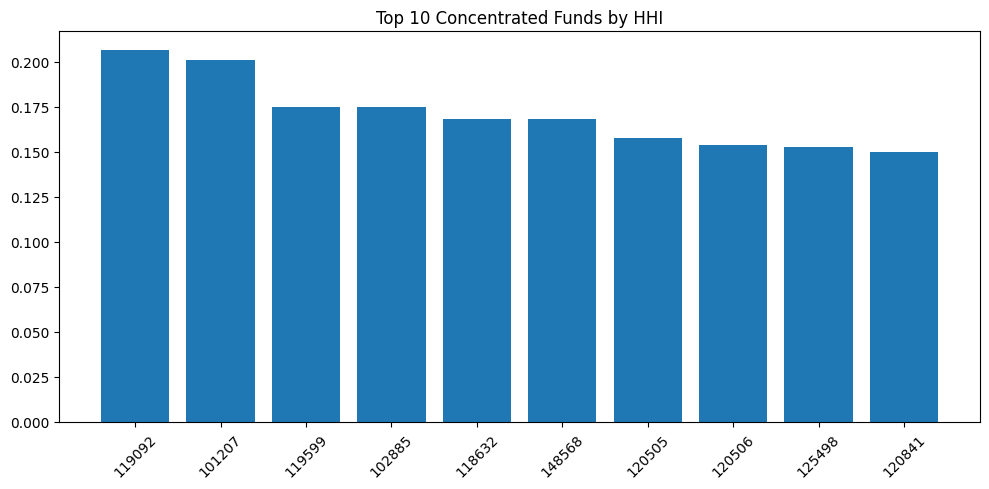

In [55]:
top_hhi = hhi.sort_values(
    "HHI",
    ascending=False
).head(10)

plt.figure(figsize=(10,5))

plt.bar(
    top_hhi["amfi_code"].astype(str),
    top_hhi["HHI"]
)

plt.title("Top 10 Concentrated Funds by HHI")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../reports/hhi_chart.png"
)

plt.show()

In [56]:
portfolio = pd.read_csv("../data/raw/09_portfolio_holdings.csv")
print(portfolio.columns)

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='str')


# Advanced Insights

## Insight 1
Funds with the highest VaR values exhibit the greatest downside risk and are more vulnerable during market downturns.

## Insight 2
Recent investor cohorts contributed the highest average investment amounts, indicating increasing participation in mutual funds.

## Insight 3
Rolling Sharpe Ratios fluctuate significantly over time, showing that risk-adjusted performance is dynamic and market-dependent.

## Insight 4
A portion of SIP investors have gaps exceeding 35 days between contributions, suggesting potential discontinuation risk.

## Insight 5
Funds with higher HHI values have concentrated portfolios and are more exposed to sector-specific volatility.

In [57]:
import os

print(os.listdir("../reports"))

['age_group_distribution.png', 'alpha_beta.csv', 'aum_growth.png', 'benchmark_comparison.png', 'BLUESTOCK MUTUAL FUND DASHBOARD.pdf', 'bluestock_mf_dashboard.pbix', 'cagr_comparison.csv', 'category_heatmap.png', 'cohort_analysis.csv', 'cohort_top_fund.csv', 'daily_return_distribution.png', 'day1_anomalies.txt', 'drawdown_periods.csv', 'expense_ratio_distribution.png', 'folio_growth.png', 'fund_category_distribution.png', 'fund_recommendations.csv', 'fund_scorecard.csv', 'fund_scorecard_chart.png', 'gender_distribution.png', 'hhi_analysis.csv', 'hhi_chart.png', 'max_drawdown.png', 'nav_correlation_matrix.png', 'nav_trend.html', 'nav_trend.png', 'return_vs_expense_ratio.png', 'risk_grade_distribution.png', 'rolling_sharpe_chart.png', 'Screenshot 2026-06-10 205605.png', 'Screenshot 2026-06-10 205615.png', 'Screenshot 2026-06-10 205627.png', 'Screenshot 2026-06-10 210028.png', 'sector_allocation_donut.png', 'sip_by_age_boxplot.png', 'sip_continuity_report.csv', 'sip_trend.png', 'state_sip_

In [58]:
print(fund_scorecard["risk_grade"].value_counts())

risk_grade
Low    40
Name: count, dtype: int64


In [59]:
print(
    fund_scorecard[
        ["amfi_code","beta","risk_grade"]
    ].head(20)
)

    amfi_code      beta risk_grade
0      100016 -0.058268        Low
1      100025  0.001158        Low
2      100033  0.005104        Low
3      101206  0.021086        Low
4      101207 -0.065289        Low
5      101208  0.000267        Low
6      102885 -0.019487        Low
7      102886 -0.042125        Low
8      102887  0.016683        Low
9      118632 -0.008354        Low
10     118633 -0.036639        Low
11     118634  0.103497        Low
12     118635 -0.001434        Low
13     118636  0.001257        Low
14     119092  0.009731        Low
15     119093  0.025883        Low
16     119094 -0.066265        Low
17     119095 -0.066951        Low
18     119120 -0.006414        Low
19     119551 -0.031751        Low
